# Magangin — Data Cleaning Pipeline

**Tujuan:** Membersihkan dataset hasil scraping `magangin_jobs_20260513_2255.csv` agar siap
digunakan untuk analisis dan pengembangan fitur rekomendasi magang.

Pembersihan mencakup:
- Menghapus noise pada kolom `company_name` (pola "ulasan" dari Glints/Kalibrr)
- Mengisi nilai null `company_name` dengan ekstraksi dari `link`
- Mengisi null `location_raw` dengan string kosong
- Menambahkan flag `is_clean`

## Load Data

Import library yang dibutuhkan dan muat dataset dari path relatif.
Kita tampilkan shape dan 3 baris pertama untuk memastikan data berhasil dimuat.

In [80]:
import pandas as pd
import re
import numpy as np
from IPython.display import display

RAW_PATH = "../data/magangin_jobs_20260513_2255.csv"
df = pd.read_csv(RAW_PATH)

In [81]:
ORIGINAL_ROW_COUNT = len(df)   

print(f"Shape  : {df.shape}")
print(f"Kolom  : {list(df.columns)}")
print()
df.head()

Shape  : (201, 17)
Kolom  : ['source', 'title', 'link', 'location_raw', 'company_name', 'description_raw', 'skills', 'skills_count', 'role', 'location_city', 'region', 'jogja_tag', 'jabodetabek_tag', 'scraped_at', 'roadmap_url', 'is_tech', 'score']



,source,title,link,location_raw,company_name,description_raw,skills,skills_count,role,location_city,region,jogja_tag,jabodetabek_tag,scraped_at,roadmap_url,is_tech,score
0,jobstreet,Full Stack / Mobile Developer & AI Engineer,https://id.jobstreet.com/id/job/92065430,Jakarta Barat,PT Qonex Indonesia Solusi,"Job Desc:\n\nMerancang, mengembangkan, dan mem...","android, api, cicd, css, express, flutter, go,...",26,backend,jakarta,Jabodetabek,False,True,2026-05-13 22:35:39,https://roadmap.sh/backend,True,84
1,jobstreet,Junior Software Engineer,https://id.jobstreet.com/id/job/91648206,Jakarta Raya,PT Technet Vision Indonesia,Qualifications\n\nCore Requirements\n\nBachelo...,"agile, angular, api, aws, cicd, css, docker, g...",23,backend,jakarta,Jabodetabek,False,True,2026-05-13 22:27:15,https://roadmap.sh/backend,True,75
2,jobstreet,Full Stack AI Developer,https://id.jobstreet.com/id/job/91502813,Jakarta Pusat,PT Kharsima Alpha Teknologi,About the Role\n\nWe are looking for a Full St...,"api, aws, azure, cicd, css, django, docker, fa...",23,backend,jakarta,Jabodetabek,False,True,2026-05-13 22:38:00,https://roadmap.sh/backend,True,75
3,jobstreet,Backend Programmer,https://id.jobstreet.com/id/job/92000167,Jakarta Raya,PT Nutech Integrasi,"Position Objective:\n\nTo develop, maintain, a...","accessibility, api, automation, css, database,...",21,backend,jakarta,Jabodetabek,False,True,2026-05-13 22:25:42,https://roadmap.sh/backend,True,69
4,jobstreet,Quality Assurance (Internship),https://id.jobstreet.com/id/job/92038778,Bandung Barat,PT Lincah Cipta Harapan,Qualifications: \n\nBachelor's degree in Compu...,"agile, android, automation, firebase, flutter,...",21,frontend,bandung,Jawa Barat,False,False,2026-05-13 22:47:38,https://roadmap.sh/frontend,True,68


# Assess 

In [82]:
from jcopml.plot import plot_missing_value

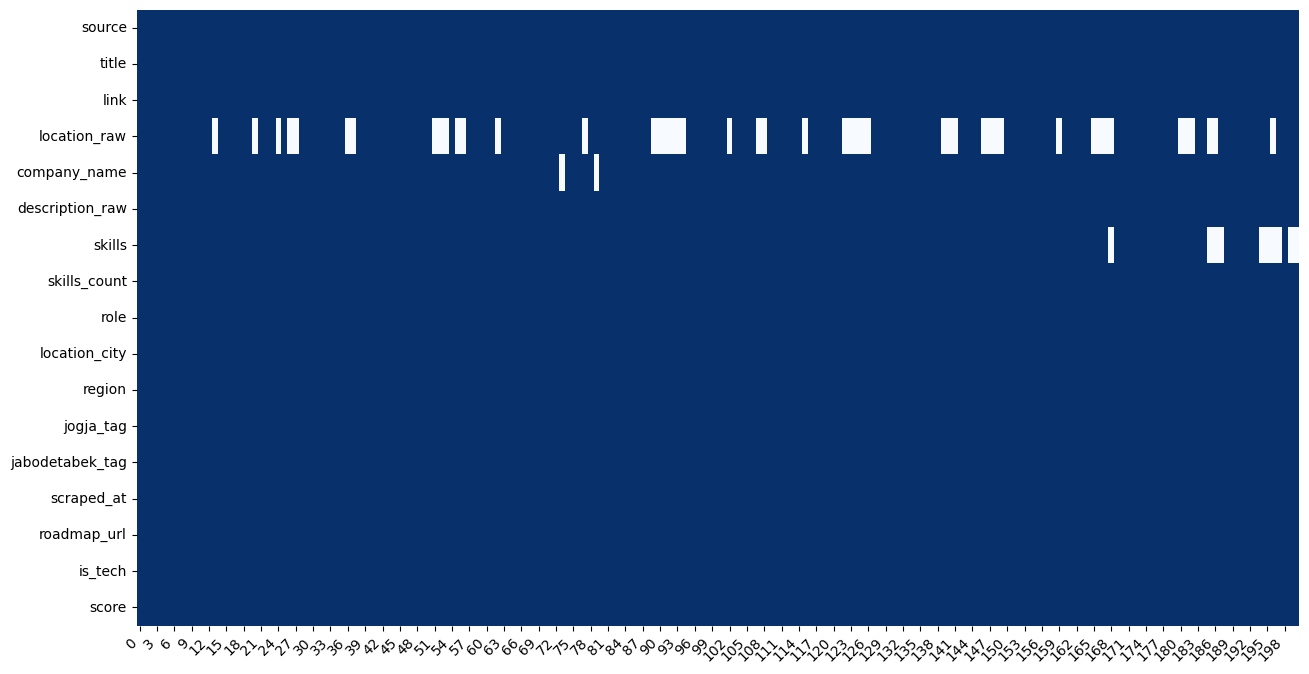

In [83]:
plot_missing_value(df)

In [84]:
missing = df.isnull().sum()
missing_nonzero = missing[missing > 0]

print("=" * 45)
print(" Missing Values per Kolom (hanya > 0)")
print("=" * 45)
if missing_nonzero.empty:
    print("  ✅ Tidak ada nilai null.")
else:
    print(missing_nonzero.to_string())
print()

 Missing Values per Kolom (hanya > 0)
location_raw    47
company_name     2
skills          10



## Fix company_name

**Strategi pembersihan (berurutan):**

1. **Regex strip** — hapus pola `<angka> ulasan` dari string `company_name` (noise dari Glints).
2. **Strip whitespace** — bersihkan spasi sisa di awal/akhir.
3. **Fallback dari `link`** — jika masih null setelah langkah 1–2, ekstrak nama perusahaan dari URL:
   - **Kalibrr**: pola `/c/<slug>/jobs/` → slug di-title-case, `-` → spasi
   - **Glints**: pola `/companies/<slug>/` → idem
4. **Default** — jika tidak ada pola yang cocok → `"Unknown"`

In [85]:
original_company = df["company_name"].copy()

# ---------------------------------------------------------------------------
# Hapus pola "\d+ ulasan" (case-insensitive)
# ---------------------------------------------------------------------------
df["company_name"] = df["company_name"].fillna("").str.replace(
    r"\s*\d+\s*ulasan", "", case=False, regex=True
)

df["company_name"] = df["company_name"].str.strip()

# Ubah string kosong hasil strip menjadi NaN agar fallback bisa jalan
df["company_name"] = df["company_name"].replace("", np.nan)

# ---------------------------------------------------------------------------
# Fallback: ekstrak nama dari kolom link
# ---------------------------------------------------------------------------
def extract_company_from_link(link: str) -> str:
    """Ekstrak nama perusahaan dari URL Kalibrr atau Glints."""
    if not isinstance(link, str):
        return "Unknown"

    # Kalibrr: https://www.kalibrr.id/c/<slug>/jobs/...
    m = re.search(r"/c/([^/]+)/jobs", link)
    if m:
        return m.group(1).replace("-", " ").title()

    # Glints: https://glints.com/id/opportunities/jobs/.../companies/<slug>/...
    #         atau https://glints.com/.../companies/<slug>/
    m = re.search(r"/companies/([^/]+)/", link)
    if m:
        return m.group(1).replace("-", " ").title()

    return "Unknown"


null_mask = df["company_name"].isnull()
if null_mask.any():
    df.loc[null_mask, "company_name"] = df.loc[null_mask, "link"].apply(
        extract_company_from_link
    )

# ---------------------------------------------------------------------------
# Print before vs after untuk baris yang berubah
# ---------------------------------------------------------------------------
changed_mask = original_company.fillna("") != df["company_name"].fillna("")
changed_count = changed_mask.sum()

print(f"Jumlah baris yang berubah : {changed_count}")
print()

if changed_count > 0:
    comparison = pd.DataFrame({
        "BEFORE": original_company[changed_mask].values,
        "AFTER" : df.loc[changed_mask, "company_name"].values,
        "link"  : df.loc[changed_mask, "link"].values,
    })
    print("=" * 70)
    print(" Before vs After — company_name")
    print("=" * 70)
    display(comparison)

Jumlah baris yang berubah : 2

 Before vs After — company_name


,BEFORE,AFTER,link
0,NaN,Unknown,https://id.jobstreet.com/id/job/91484482
1,NaN,Unknown,https://id.jobstreet.com/id/job/91464109


In [86]:
# ---------------------------------------------------------------------------
# skills null → dibiarkan (tidak diubah)
# ---------------------------------------------------------------------------
print(f"skills null       → TETAP : {df['skills'].isnull().sum()} (tidak diubah)")

# ---------------------------------------------------------------------------
# 4c. Tambah kolom is_clean = True
# ---------------------------------------------------------------------------
df["is_clean"] = True

print()
print(f"Kolom is_clean ditambahkan → semua baris: {df['is_clean'].all()}")
print(f"Shape setelah handle nulls : {df.shape}")

skills null       → TETAP : 10 (tidak diubah)

Kolom is_clean ditambahkan → semua baris: True
Shape setelah handle nulls : (201, 18)


In [87]:
missing_after = df.isnull().sum()
missing_after_nonzero = missing_after[missing_after > 0]

print("=" * 45)
print(" Missing Values SETELAH Cleaning")
print("=" * 45)
if missing_after_nonzero.empty:
    print("  ✅ Tidak ada nilai null.")
else:
    print(missing_after_nonzero.to_string())
print()

# ---------------------------------------------------------------------------
# Jumlah baris sebelum vs sesudah
# ---------------------------------------------------------------------------
EXPECTED_ROWS = ORIGINAL_ROW_COUNT  
actual_rows = len(df)
row_status = "✅ OK" if actual_rows == EXPECTED_ROWS else "❌ MISMATCH"

print(f"Jumlah baris sebelum cleaning : {EXPECTED_ROWS}")
print(f"Jumlah baris sesudah cleaning : {actual_rows}  {row_status}")
print()

# ---------------------------------------------------------------------------
# Null count untuk kolom kritis
# ---------------------------------------------------------------------------
print("=" * 45)
print(" Null Count — Kolom Kritis")
print("=" * 45)
display(
    df[["company_name", "title", "skills"]]
    .isnull()
    .sum()
    .rename("null_count")
    .to_frame()
)

 Missing Values SETELAH Cleaning
location_raw    47
skills          10

Jumlah baris sebelum cleaning : 201
Jumlah baris sesudah cleaning : 201  ✅ OK

 Null Count — Kolom Kritis


,null_count
company_name,0
title,0
skills,10


## Drop Kolom yang Tidak Dibutuhkan

Kolom-kolom berikut dihapus karena bersifat **raw/intermediate** dan tidak diperlukan untuk analisis atau rekomendasi:

| Kolom | Alasan Drop |
|---|---|
| `location_raw` | Sudah diekstrak ke `location_city` + `region` |
| `description_raw` | Terlalu panjang, sudah digunakan untuk ekstraksi `skills` |
| `jogja_tag` | Redundan — sudah tercakup dalam `region == 'Yogyakarta'` |
| `jabodetabek_tag` | Redundan — sudah tercakup dalam `region == 'Jabodetabek'` |
| `is_tech` | Redundan — semua baris lolos karena sudah difilter tech-only |
| `score` | Skor pipeline lama, akan dihitung ulang jika diperlukan |

In [88]:
# ---------------------------------------------------------------------------
# Drop kolom yang tidak dibutuhkan
# ---------------------------------------------------------------------------
COLS_TO_DROP = ["location_raw", "description_raw", "jogja_tag", "jabodetabek_tag", "is_tech", "score", "scraped_at", "is_clean"]

# Hanya drop kolom yang memang ada di dataframe
existing_drop = [c for c in COLS_TO_DROP if c in df.columns]
missing_drop  = [c for c in COLS_TO_DROP if c not in df.columns]

df = df.drop(columns=existing_drop)

print(f"Kolom yang di-drop ({len(existing_drop)})  : {existing_drop}")
if missing_drop:
    print(f"Kolom tidak ditemukan (skip)  : {missing_drop}")
print(f"\nShape setelah drop kolom : {df.shape}")
print(f"Kolom tersisa            : {list(df.columns)}")

Kolom yang di-drop (8)  : ['location_raw', 'description_raw', 'jogja_tag', 'jabodetabek_tag', 'is_tech', 'score', 'scraped_at', 'is_clean']

Shape setelah drop kolom : (201, 10)
Kolom tersisa            : ['source', 'title', 'link', 'company_name', 'skills', 'skills_count', 'role', 'location_city', 'region', 'roadmap_url']


## Handle Missing Skills — Roadmap Mapping

**Strategi (berurutan):**

1. **Roadmap lookup** — ambil representative skills dari `skills_per_role.json` berdasarkan `role` yang terdeteksi.
   - Role → roadmap key mapping:
     - `data`       → `data-analyst`
     - `ai/ml`      → `ai-data-scientist`
     - `backend`    → `backend`
     - `it-general` → `backend` + `frontend` (IT support butuh kedua sisi)
     - dll
2. **Filter skills** — ambil skills yang ada di `SKILLS_DB` (canonical & relevan), bukan raw roadmap terms.
3. **Drop** — baris yang rolenya tidak bisa di-handle (non-tech / role = `other`).

In [89]:
import json, sys, os
sys.path.insert(0, os.path.abspath(".."))

# ---------------------------------------------------------------------------
# Load skills_per_role.json dari roadmap output
# ---------------------------------------------------------------------------
ROADMAP_SKILLS_PATH = "../scrapper/roadmap/output/skills_per_role.json"

with open(ROADMAP_SKILLS_PATH, "r", encoding="utf-8") as f:
    ROADMAP_SKILLS = json.load(f)

print(f"Roadmap roles tersedia : {list(ROADMAP_SKILLS.keys())}")
print(f"\nContoh skills 'data-analyst' (5 pertama): {ROADMAP_SKILLS.get('data-analyst', [])[:5]}")

Roadmap roles tersedia : ['frontend', 'backend', 'fullstack', 'devops', 'python', 'javascript', 'typescript', 'react', 'nodejs', 'android', 'ios', 'flutter', 'data-analyst', 'ai-data-scientist', 'mlops', 'cyber-security', 'qa', 'ux-design', 'docker', 'kubernetes']

Contoh skills 'data-analyst' (5 pertama): ['1) predicting sales trends 2) customer segmentation.', 'advanced topics', 'ai and data scientist roadmap', 'analysis / reporting with excel', 'apis']


In [90]:
from scrapper.config import SKILLS_DB, NORMALIZATION_MAP

# ---------------------------------------------------------------------------
# Buat flat lookup: keyword roadmap → canonical skill name
# ---------------------------------------------------------------------------
VALID_SKILLS = set(SKILLS_DB.keys())

ROADMAP_KW_TO_SKILL = {}
for skill, keywords in SKILLS_DB.items():
    for kw in keywords:
        ROADMAP_KW_TO_SKILL[kw.lower()] = skill

# ---------------------------------------------------------------------------
# Mapping: role df → roadmap key(s)
# ---------------------------------------------------------------------------
# Catatan: "ai-data-scientist" di skills_per_role.json berisi paper/article/course names
# bukan tech skill terms → tidak ada match ke SKILLS_DB.
# Untuk ai/ml digunakan FALLBACK_SKILLS langsung (hardcoded representatif).
ROLE_TO_ROADMAP_KEYS = {
    "data":       ["data-analyst"],
    "backend":    ["backend"],
    "frontend":   ["frontend"],
    "fullstack":  ["fullstack"],
    "devops":     ["devops"],
    "mobile":     ["android", "flutter", "ios"],
    "qa":         ["qa"],
    "cyber":      ["cyber-security"],
    "ui/ux":      ["ux-design"],
    "it-general": ["backend", "frontend"],   # broad: IT Support/Intern
    # ai/ml → tidak ada roadmap key (ai-data-scientist tidak punya tech terms)
    #         akan langsung pakai FALLBACK_SKILLS
}

# Hardcoded fallback untuk role yang roadmap-nya tidak punya tech skill terms
FALLBACK_SKILLS = {
    "ai/ml": "python, tensorflow, pytorch, sklearn, pandas, numpy, sql, git",
}

def get_skills_from_roadmap(role: str, max_skills: int = 8):
    # Coba roadmap lookup dulu
    roadmap_keys = ROLE_TO_ROADMAP_KEYS.get(role)
    if roadmap_keys:
        found = set()
        for key in roadmap_keys:
            for term in ROADMAP_SKILLS.get(key, []):
                t = term.lower()
                if t in VALID_SKILLS:
                    found.add(t)
                elif t in ROADMAP_KW_TO_SKILL:
                    found.add(ROADMAP_KW_TO_SKILL[t])
        if found:
            return ", ".join(sorted(found)[:max_skills])

    # Fallback hardcoded jika roadmap lookup gagal atau role tidak ada di mapping
    return FALLBACK_SKILLS.get(role, None)


# Uji coba
for test_role in ["data", "ai/ml", "it-general", "backend", "other"]:
    result = get_skills_from_roadmap(test_role)
    print(f"  [{test_role:12s}] → {result}")

  [data        ] → pandas, powerbi, python, pytorch, spark, tableau, tensorflow
  [ai/ml       ] → python, tensorflow, pytorch, sklearn, pandas, numpy, sql, git
  [it-general  ] → accessibility, angular, apollo, astro, bitbucket, cloud, css, docker
  [backend     ] → bitbucket, cloud, docker, elasticsearch, firebase, git, go, graphql
  [other       ] → None


In [91]:
# ---------------------------------------------------------------------------
# Handle Missing Skills untuk it-general secara dinamis
# ---------------------------------------------------------------------------

def impute_it_skills(title):
    title_lower = title.lower()
    skills = []
    
    # 1. Jika title mengandung unsur Programmer/Software Engineer
    if any(k in title_lower for k in ["software", "programmer", "developer"]):
        skills.extend(["git", "sql", "javascript", "python"])
    
    # 2. Jika title berkaitan dengan IT Support/Admin/Intern umum
    elif any(k in title_lower for k in ["support", "admin", "internship", "intern"]):
        skills.extend(["networking", "database", "linux", "security"])
        
    # 3. Default fallback jika tidak masuk ke mana-mana
    else:
        skills.extend(["database", "agile"])
        
    return ", ".join(skills)

# Isi nilai yang null dengan fungsi di atas
null_mask = df["skills"].isnull()
df.loc[null_mask, "skills"] = df.loc[null_mask, "title"].apply(impute_it_skills)

# Update skills_count
df.loc[null_mask, "skills_count"] = df.loc[null_mask, "skills"].apply(lambda x: len(x.split(", ")))

# Verifikasi hasil
print(f"Baris dengan skills null setelah imputasi: {df['skills'].isnull().sum()}")
display(df.loc[null_mask, ["title", "role", "skills", "skills_count"]])


Baris dengan skills null setelah imputasi: 0


,title,role,skills,skills_count
168,IT Support Intern,it-general,"networking, database, linux, security",4
185,IT Intern,it-general,"networking, database, linux, security",4
186,IT Intern,it-general,"networking, database, linux, security",4
187,"Customer Service, Account Officer, Kepala Bagi...",it-general,"networking, database, linux, security",4
194,IT INTERNSHIP,it-general,"networking, database, linux, security",4
195,Junior Software Engineer (Fresh Graduate),it-general,"git, sql, javascript, python",4
196,IT Support Intern,it-general,"networking, database, linux, security",4
197,Intern Care Officer (IT Support & Customer Ser...,it-general,"networking, database, linux, security",4
199,Software & PLC Programmer,it-general,"git, sql, javascript, python",4
200,IT support,it-general,"networking, database, linux, security",4


In [92]:
null_skills_mask = df["skills"].isnull()
null_skills_df   = df[null_skills_mask].copy()

print(f"Baris dengan skills null : {null_skills_mask.sum()}")

Baris dengan skills null : 0


In [93]:
# ---------------------------------------------------------------------------
# 7e. Isi skills null dari roadmap mapping, tandai yang gagal
# ---------------------------------------------------------------------------
filled_count = 0
unfilled_idx  = []

for idx in df[null_skills_mask].index:
    role     = df.at[idx, "role"]
    inferred = get_skills_from_roadmap(role)
    if inferred:
        df.at[idx, "skills"]       = inferred
        df.at[idx, "skills_count"] = len(inferred.split(", "))
        filled_count += 1
    else:
        unfilled_idx.append(idx)

print(f"Skills berhasil diisi dari roadmap : {filled_count} baris")
print(f"Skills tidak bisa diisi (akan di-drop) : {len(unfilled_idx)} baris")

if unfilled_idx:
    print("\nBaris yang akan di-drop:")
    display(df.loc[unfilled_idx, ["title", "role", "skills"]])

Skills berhasil diisi dari roadmap : 0 baris
Skills tidak bisa diisi (akan di-drop) : 0 baris


In [94]:
# ---------------------------------------------------------------------------
# 7f. Drop baris yang skills-nya masih null (tidak bisa di-handle)
# ---------------------------------------------------------------------------
before_drop = len(df)

if unfilled_idx:
    df = df.drop(index=unfilled_idx).reset_index(drop=True)

after_drop       = len(df)
remaining_null   = df["skills"].isnull().sum()

print(f"Baris sebelum drop : {before_drop}")
print(f"Baris di-drop      : {before_drop - after_drop}")
print(f"Baris tersisa      : {after_drop}")
print(f"Skills null tersisa: {remaining_null}  {'✅' if remaining_null == 0 else '⚠️ masih ada null'}")
print(f"\nShape final        : {df.shape}")

Baris sebelum drop : 201
Baris di-drop      : 0
Baris tersisa      : 201
Skills null tersisa: 0  ✅

Shape final        : (201, 10)


## Validate — After Full Cleaning

Validasi akhir setelah semua tahap cleaning selesai:
- Tidak ada null pada kolom kritis
- Distribusi role masih wajar
- Kolom final sesuai ekspektasi

In [95]:
# ---------------------------------------------------------------------------
# Summary missing values final
# ---------------------------------------------------------------------------
missing_final = df.isnull().sum()
missing_final_nonzero = missing_final[missing_final > 0]

print("=" * 50)
print(" Missing Values — FINAL")
print("=" * 50)
if missing_final_nonzero.empty:
    print("  ✅ Tidak ada nilai null pada kolom manapun.")
else:
    print(missing_final_nonzero.to_string())

print()
print("=" * 50)
print(" Distribusi Role")
print("=" * 50)
print(df["role"].value_counts().to_string())

print()
print("=" * 50)
print(" Kolom Final")
print("=" * 50)
print(list(df.columns))
print(f"\nShape final : {df.shape}")

 Missing Values — FINAL
  ✅ Tidak ada nilai null pada kolom manapun.

 Distribusi Role
role
backend       45
it-general    36
frontend      21
cyber         20
qa            19
ai/ml         15
devops        14
ui/ux         12
data          10
fullstack      7
mobile         2

 Kolom Final
['source', 'title', 'link', 'company_name', 'skills', 'skills_count', 'role', 'location_city', 'region', 'roadmap_url']

Shape final : (201, 10)


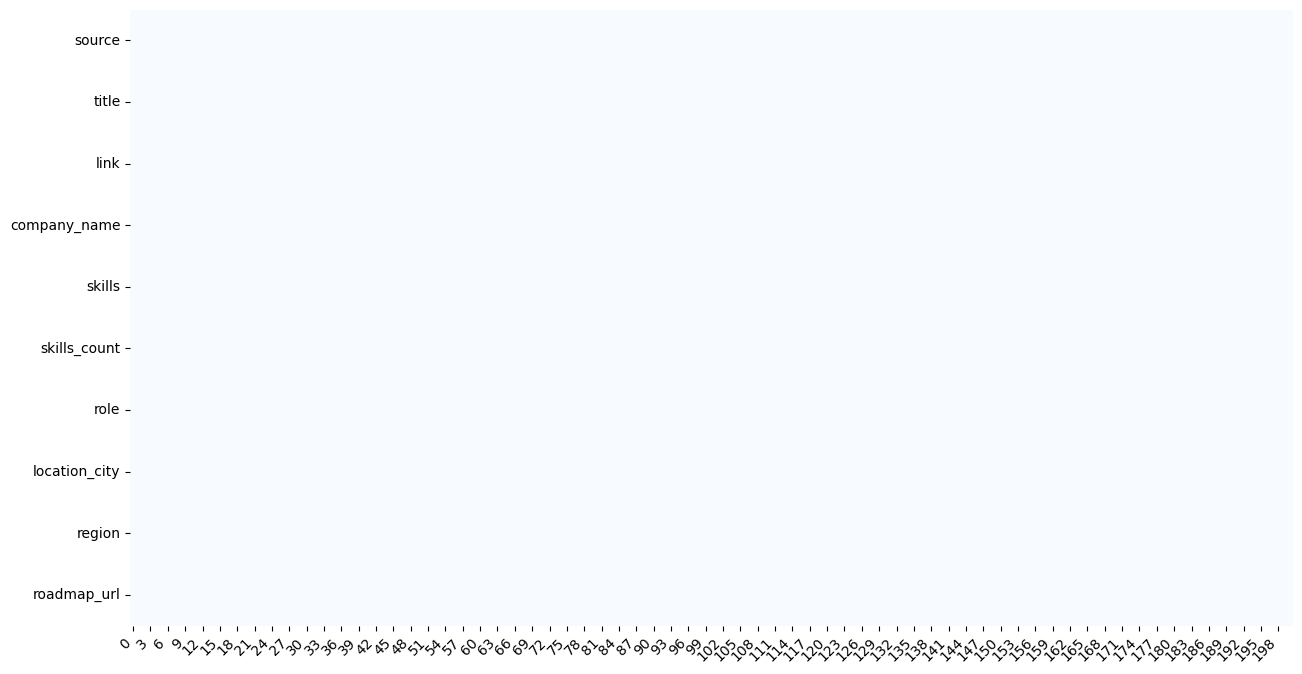

In [96]:
# ---------------------------------------------------------------------------
# Sample output
# ---------------------------------------------------------------------------
df.head()
plot_missing_value(df)

## Save Output

Simpan dataframe yang sudah bersih ke file baru **tanpa** menimpa file asli.

- Output: `../data/magangin_jobs_cleaned.csv`
- Encoding: `utf-8-sig` (BOM) agar Excel membacanya dengan benar
- File asli `magangin_jobs_20260510_1527.csv` **tidak disentuh**

In [97]:
import os

OUTPUT_PATH = "../data/magangin_jobs_cleaned.csv"

# Guardrail: pastikan tidak menimpa file raw
assert OUTPUT_PATH != RAW_PATH, "Output path sama dengan file asli! Batalkan."

# Simpan
df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

# Konfirmasi
abs_path   = os.path.abspath(OUTPUT_PATH)
saved_rows = len(pd.read_csv(OUTPUT_PATH))

print("File berhasil disimpan!")
print(f"   Path  : {abs_path}")
print(f"   Baris : {saved_rows} baris tersimpan")
print(f"   Kolom : {list(df.columns)}")
print()
print("=" * 55)
print(" Ringkasan Pipeline Cleaning")
print("=" * 55)
print(f"  Baris awal (raw)              : {ORIGINAL_ROW_COUNT}")
print(f"  Kolom di-drop                 : {len(existing_drop)} kolom → {existing_drop}")
print(f"  Skills diisi dari roadmap     : {filled_count} baris")
print(f"  Baris di-drop (tidak bisa diisi): {before_drop - after_drop} baris")
print(f"  Baris final tersimpan         : {saved_rows} baris")

File berhasil disimpan!
   Path  : /Users/admin/Desktop/noobies/DBS DS/magangin/data/magangin_jobs_cleaned.csv
   Baris : 201 baris tersimpan
   Kolom : ['source', 'title', 'link', 'company_name', 'skills', 'skills_count', 'role', 'location_city', 'region', 'roadmap_url']

 Ringkasan Pipeline Cleaning
  Baris awal (raw)              : 201
  Kolom di-drop                 : 8 kolom → ['location_raw', 'description_raw', 'jogja_tag', 'jabodetabek_tag', 'is_tech', 'score', 'scraped_at', 'is_clean']
  Skills diisi dari roadmap     : 0 baris
  Baris di-drop (tidak bisa diisi): 0 baris
  Baris final tersimpan         : 201 baris
